Annual Enterprise Survey Analysis

This project analyzes financial survey data using Python, Pandas, Matplotlib, and Seaborn.

Objectives
- Clean and preprocess raw survey data
- Handle inconsistent and missing values
- Explore trends across years
- Visualize key business insights

Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\USER\Downloads\annual-enterprise-survey-2011-2024-financial years.csv")

In [4]:
df.head()

,year,industry_code_ANZSIC,industry_name_ANZSIC,rme_size_grp,variable,value,unit,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,2011,A,"Agriculture, Forestry and Fishing",a_0,Activity unit,46134,COUNT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011,A,"Agriculture, Forestry and Fishing",a_0,Rolling mean employees,0,COUNT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2011,A,"Agriculture, Forestry and Fishing",a_0,Salaries and wages paid,279,DOLLARS(millions),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2011,A,"Agriculture, Forestry and Fishing",a_0,"Sales, government funding, grants and subsidies",8187,DOLLARS(millions),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2011,A,"Agriculture, Forestry and Fishing",a_0,Total income,8866,DOLLARS(millions),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Obtaining Basic Information About the Data

In [5]:
df.shape

(21672, 16)

In [6]:
print(df.columns.tolist())

['year', 'industry_code_ANZSIC', 'industry_name_ANZSIC', 'rme_size_grp', 'variable', 'value', 'unit', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21672 entries, 0 to 21671
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  21672 non-null  int64  
 1   industry_code_ANZSIC  21672 non-null  object 
 2   industry_name_ANZSIC  21672 non-null  object 
 3   rme_size_grp          21672 non-null  object 
 4   variable              21672 non-null  object 
 5   value                 21672 non-null  object 
 6   unit                  21672 non-null  object 
 7   Unnamed: 7            0 non-null      float64
 8   Unnamed: 8            0 non-null      float64
 9   Unnamed: 9            41 non-null     float64
 10  Unnamed: 10           41 non-null     object 
 11  Unnamed: 11           41 non-null     object 
 12  Unnamed: 12           41 non-null     object 
 13  Unnamed: 13           41 non-null     object 
 14  Unnamed: 14           41 non-null     object 
 15  Unnamed: 15        

Data Cleaning

The dataset contains missing values, inconsistent entries, and suppressed values represented by "C".  
This section cleans the dataset to prepare it for analysis.

In [8]:
# Drop the fully empty columns
df = df.dropna(axis=1, how='all')

print(df.shape)    

# Check remaining columns
print(df.columns.tolist()) 

(21672, 14)
['year', 'industry_code_ANZSIC', 'industry_name_ANZSIC', 'rme_size_grp', 'variable', 'value', 'unit', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15']


In [9]:
#Drop the rows that have values in the majority empty colums
empty_cols = df.columns[8:]  
rows_to_drop = df[df[empty_cols].notna().any(axis=1)].index
df = df.drop(index=rows_to_drop)

#Drop the now fully-empty columns
df = df.dropna(axis=1, how='all')

#Check the new colums
print(df.columns.tolist())

['year', 'industry_code_ANZSIC', 'industry_name_ANZSIC', 'rme_size_grp', 'variable', 'value', 'unit']


In [11]:
df.head()

,year,industry_code_ANZSIC,industry_name_ANZSIC,rme_size_grp,variable,value,unit
0,2011,A,"Agriculture, Forestry and Fishing",a_0,Activity unit,46134,COUNT
1,2011,A,"Agriculture, Forestry and Fishing",a_0,Rolling mean employees,0,COUNT
2,2011,A,"Agriculture, Forestry and Fishing",a_0,Salaries and wages paid,279,DOLLARS(millions)
3,2011,A,"Agriculture, Forestry and Fishing",a_0,"Sales, government funding, grants and subsidies",8187,DOLLARS(millions)
4,2011,A,"Agriculture, Forestry and Fishing",a_0,Total income,8866,DOLLARS(millions)


In [13]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 21631 entries, 0 to 21671
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   year                  21631 non-null  int64 
 1   industry_code_ANZSIC  21631 non-null  object
 2   industry_name_ANZSIC  21631 non-null  object
 3   rme_size_grp          21631 non-null  object
 4   variable              21631 non-null  object
 5   value                 21631 non-null  object
 6   unit                  21631 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.3+ MB


Checking for inconsistency in the "Value" column (Should have integers or float only, not objects)

In [14]:
suppressed = df[df["value"] == "C"]

In [15]:
suppressed.head()

,year,industry_code_ANZSIC,industry_name_ANZSIC,rme_size_grp,variable,value,unit
62,2011,A,"Agriculture, Forestry and Fishing",g_100-199,Fixed tangible assets,C,DOLLARS(millions)
71,2011,A,"Agriculture, Forestry and Fishing",h_200+,Fixed tangible assets,C,DOLLARS(millions)
102,2011,B,Mining,c_6-9,"Sales, government funding, grants and subsidies",C,DOLLARS(millions)
123,2011,B,Mining,e_20-49,Operating profit before tax,C,DOLLARS(millions)
124,2011,B,Mining,e_20-49,Total assets,C,DOLLARS(millions)


Deleting the inconsistency in values

In [16]:
# Convert 'C' (confidential/suppressed) and any non-numeric to NaN
df["value"] = pd.to_numeric(df["value"], errors="coerce")

# Drop rows where value is NaN (i.e. the suppressed 'C' rows)
df.dropna(subset=["value"], inplace=True)

Viewing the new details of the cleaned data

In [18]:
df.shape


(21248, 7)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21248 entries, 0 to 21671
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  21248 non-null  int64  
 1   industry_code_ANZSIC  21248 non-null  object 
 2   industry_name_ANZSIC  21248 non-null  object 
 3   rme_size_grp          21248 non-null  object 
 4   variable              21248 non-null  object 
 5   value                 21248 non-null  float64
 6   unit                  21248 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 1.3+ MB


In [20]:
years = df['year'].unique()
print (years)

[2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]


In [24]:
dfs_by_year = {year: df[df['year'] == year] for year in years}
df_2024 = dfs_by_year.get(2024)
df_2024.head(10)

,year,industry_code_ANZSIC,industry_name_ANZSIC,rme_size_grp,variable,value,unit
20124,2024,A,"Agriculture, Forestry and Fishing",a_0,Activity unit,40980.0,COUNT
20125,2024,A,"Agriculture, Forestry and Fishing",a_0,Fixed tangible assets,56385.0,DOLLARS(millions)
20126,2024,A,"Agriculture, Forestry and Fishing",a_0,Operating profit before tax,1710.0,DOLLARS(millions)
20127,2024,A,"Agriculture, Forestry and Fishing",a_0,Rolling mean employees,0.0,COUNT
20128,2024,A,"Agriculture, Forestry and Fishing",a_0,Salaries and wages paid,536.0,DOLLARS(millions)
20129,2024,A,"Agriculture, Forestry and Fishing",a_0,"Sales, government funding, grants and subsidies",13454.0,DOLLARS(millions)
20130,2024,A,"Agriculture, Forestry and Fishing",a_0,Total assets,98033.0,DOLLARS(millions)
20131,2024,A,"Agriculture, Forestry and Fishing",a_0,Total expenditure,12938.0,DOLLARS(millions)
20132,2024,A,"Agriculture, Forestry and Fishing",a_0,Total income,16075.0,DOLLARS(millions)
20133,2024,A,"Agriculture, Forestry and Fishing",b_1-5,Activity unit,16800.0,COUNT


In [25]:
#Function to get top 10 industries by total revenue for a given year
def top10_by_year(year):
    data = df[(df['year'] == year) & (df['industry_code_ANZSIC'] != 'all')]
    top10 = (
        data.groupby('industry_name_ANZSIC')['value']
        .sum()
        .reset_index()
        .rename(columns={
            'industry_name_ANZSIC' : 'Industry',
            'value'                : 'Total Revenue (Millions NZD)'
        })
        .sort_values('Total Revenue (Millions NZD)', ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
    top10.index += 1  # Rank from 1
    print(f"\nTop 10 Industries in {year}")
    print('=' * 60)
    print(top10.to_string())
    return top10


In [26]:
#Function to get top 10 industries by total revenue for a given year
def top10_by_year(year):
    data = df[(df['year'] == year) & (df['industry_code_ANZSIC'] != 'all')]
    top10 = (
        data.groupby('industry_name_ANZSIC')['value']
        .sum()
        .reset_index()
        .rename(columns={
            'industry_name_ANZSIC' : 'Industry',
            'value'                : 'Total Revenue (Millions NZD)'
        })
        .sort_values('Total Revenue (Millions NZD)', ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
    top10.index += 1  # Rank from 1
    print(f"\nTop 10 Industries in {year}")
    print('=' * 60)
    print(top10.to_string())
    return top10


In [27]:
#To get the top 10 industries in 2011
top10_2011 = top10_by_year (2011)


Top 10 Industries in 2011
                                           Industry  Total Revenue (Millions NZD)
1                  Financial and Insurance Services                     2411805.0
2                                     Manufacturing                     1274588.0
3                 Agriculture, Forestry and Fishing                      956289.0
4           Rental, Hiring and Real Estate Services                      875506.0
5                                      Retail Trade                      823416.0
6                                   Wholesale Trade                      787761.0
7   Professional, Scientific and Technical Services                      620627.0
8                                      Construction                      588202.0
9                 Transport, Postal and Warehousing                      448624.0
10                Health Care and Social Assistance                      433505.0


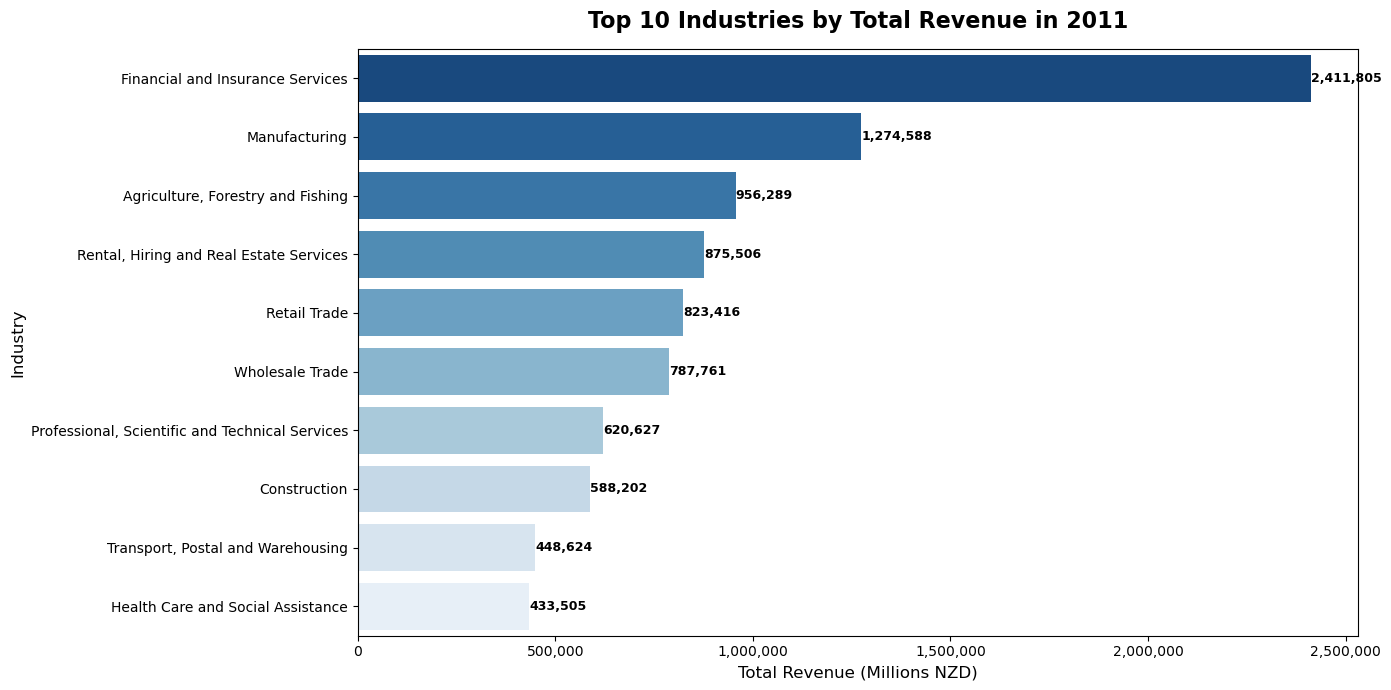

In [28]:
# Bar Chart of the top 10 Industries in 2011 
fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(
    data=top10_2011,
    x='Total Revenue (Millions NZD)',
    y='Industry',
    hue='Industry',
    palette='Blues_r',
    ax=ax,
    legend=False
)

# Labels on the bar
for bar in ax.patches:
    ax.text(
        bar.get_width() + 500,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():,.0f}',
        va='center', ha='left', fontsize=9, fontweight='bold'
    )

ax.set_title('Top 10 Industries by Total Revenue in 2011', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (Millions NZD)', fontsize=12)
ax.set_ylabel('Industry', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('top10_industries_2011.png', dpi=150, bbox_inches='tight')
plt.show()

Financial and Insurance Services generated the highest revenue in 2011, followed by Manufacturing and Agriculture. This shows that finance and production sectors were major contributors to the economy.

In [29]:
#Top 10 industries in 2024
top10_2024 =top10_by_year(2024)


Top 10 Industries in 2024
                                           Industry  Total Revenue (Millions NZD)
1                  Financial and Insurance Services                     3911987.0
2           Rental, Hiring and Real Estate Services                     1840541.0
3                                     Manufacturing                     1612214.0
4                                   Wholesale Trade                     1435150.0
5                                      Construction                     1425675.0
6                 Agriculture, Forestry and Fishing                     1373698.0
7                                      Retail Trade                     1239423.0
8   Professional, Scientific and Technical Services                     1140534.0
9                 Health Care and Social Assistance                      725435.0
10                Transport, Postal and Warehousing                      712004.0


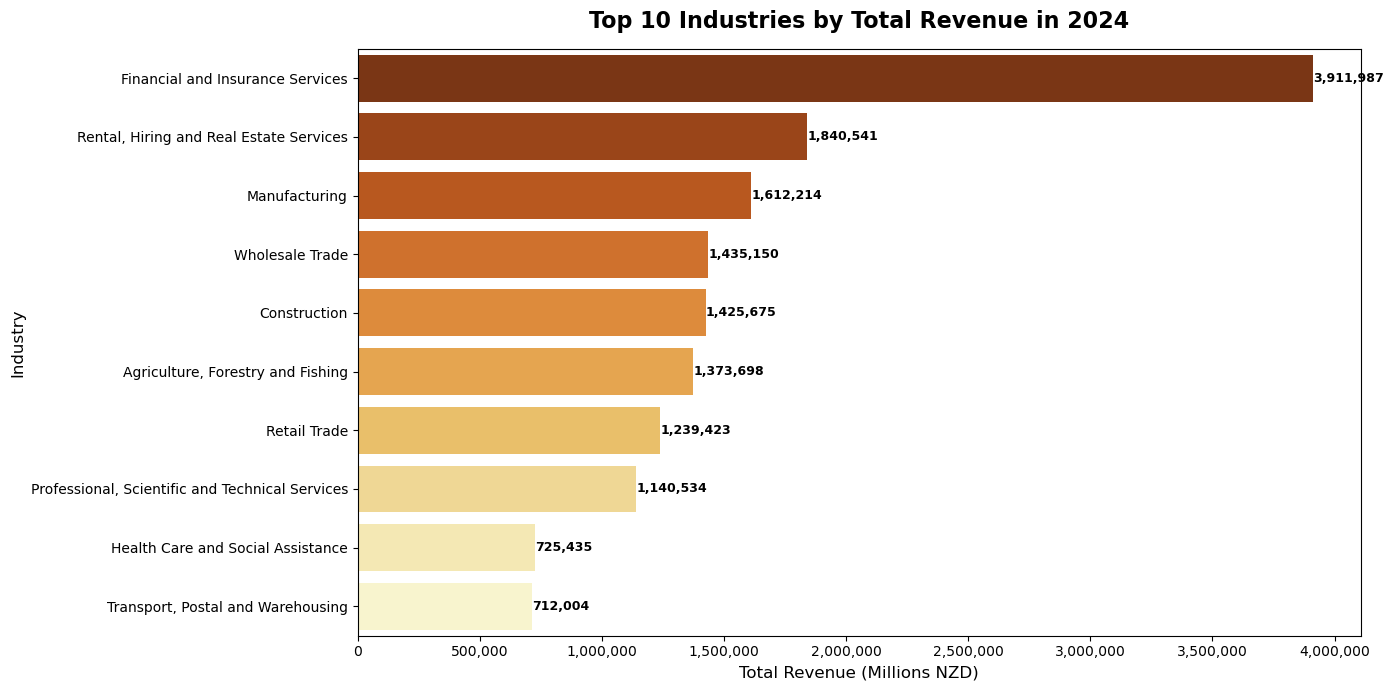

In [30]:
# Bar Chart of the Top 10 industries in 2024 
fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(
    data=top10_2024,
    x='Total Revenue (Millions NZD)',
    y='Industry',
    hue='Industry',
    palette='YlOrBr_r',
    ax=ax,
    legend=False
)

# Labels on each bar 
for bar in ax.patches:
    ax.text(
        bar.get_width() + 500,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():,.0f}',
        va='center', ha='left', fontsize=9, fontweight='bold'
    )

ax.set_title('Top 10 Industries by Total Revenue in 2024', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (Millions NZD)', fontsize=12)
ax.set_ylabel('Industry', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('top10_industries_2024.png', dpi=150, bbox_inches='tight')
plt.show()

Financial and Insurance Services remained the top-performing industry in 2024, while Real Estate and Construction showed significant growth over time.

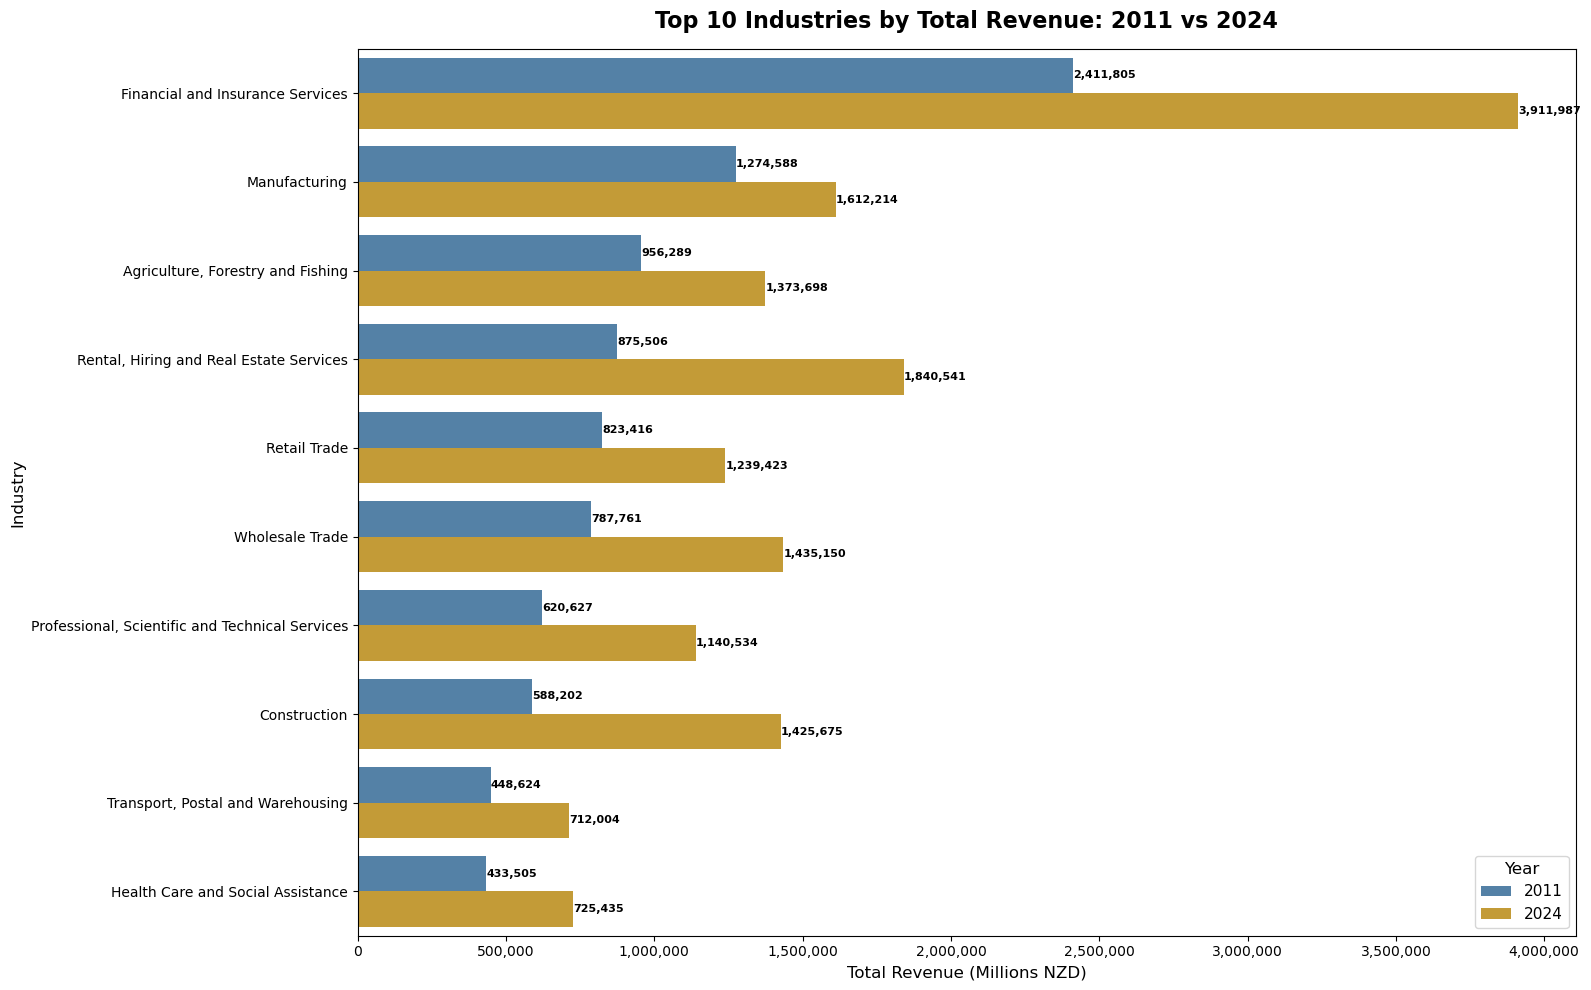

In [31]:
top10_2011['Year'] = '2011'
top10_2024['Year'] = '2024'

combined = pd.concat([top10_2011, top10_2024], ignore_index=True)

# Bar Chart of top 10 industries 2011 vs 2024 
fig, ax = plt.subplots(figsize=(16, 10))

sns.barplot(
    data=combined,
    x='Total Revenue (Millions NZD)',
    y='Industry',
    hue='Year',
    palette={'2011': 'steelblue', '2024': 'goldenrod'},
    ax=ax,
    orient='h'
)

# Labels on each bar
for bar in ax.patches:
    width = bar.get_width()
    if width > 0:
        ax.text(
            width + 500,
            bar.get_y() + bar.get_height() / 2,
            f'{width:,.0f}',
            va='center', ha='left', fontsize=8, fontweight='bold'
        )

ax.set_title('Top 10 Industries by Total Revenue: 2011 vs 2024',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (Millions NZD)', fontsize=12)
ax.set_ylabel('Industry', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(title='Year', fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.savefig('top10_industries_2011_vs_2024.png', dpi=150, bbox_inches='tight')
plt.show()

Most industries recorded strong revenue growth between 2011 and 2024, indicating overall economic expansion and increased business activity.

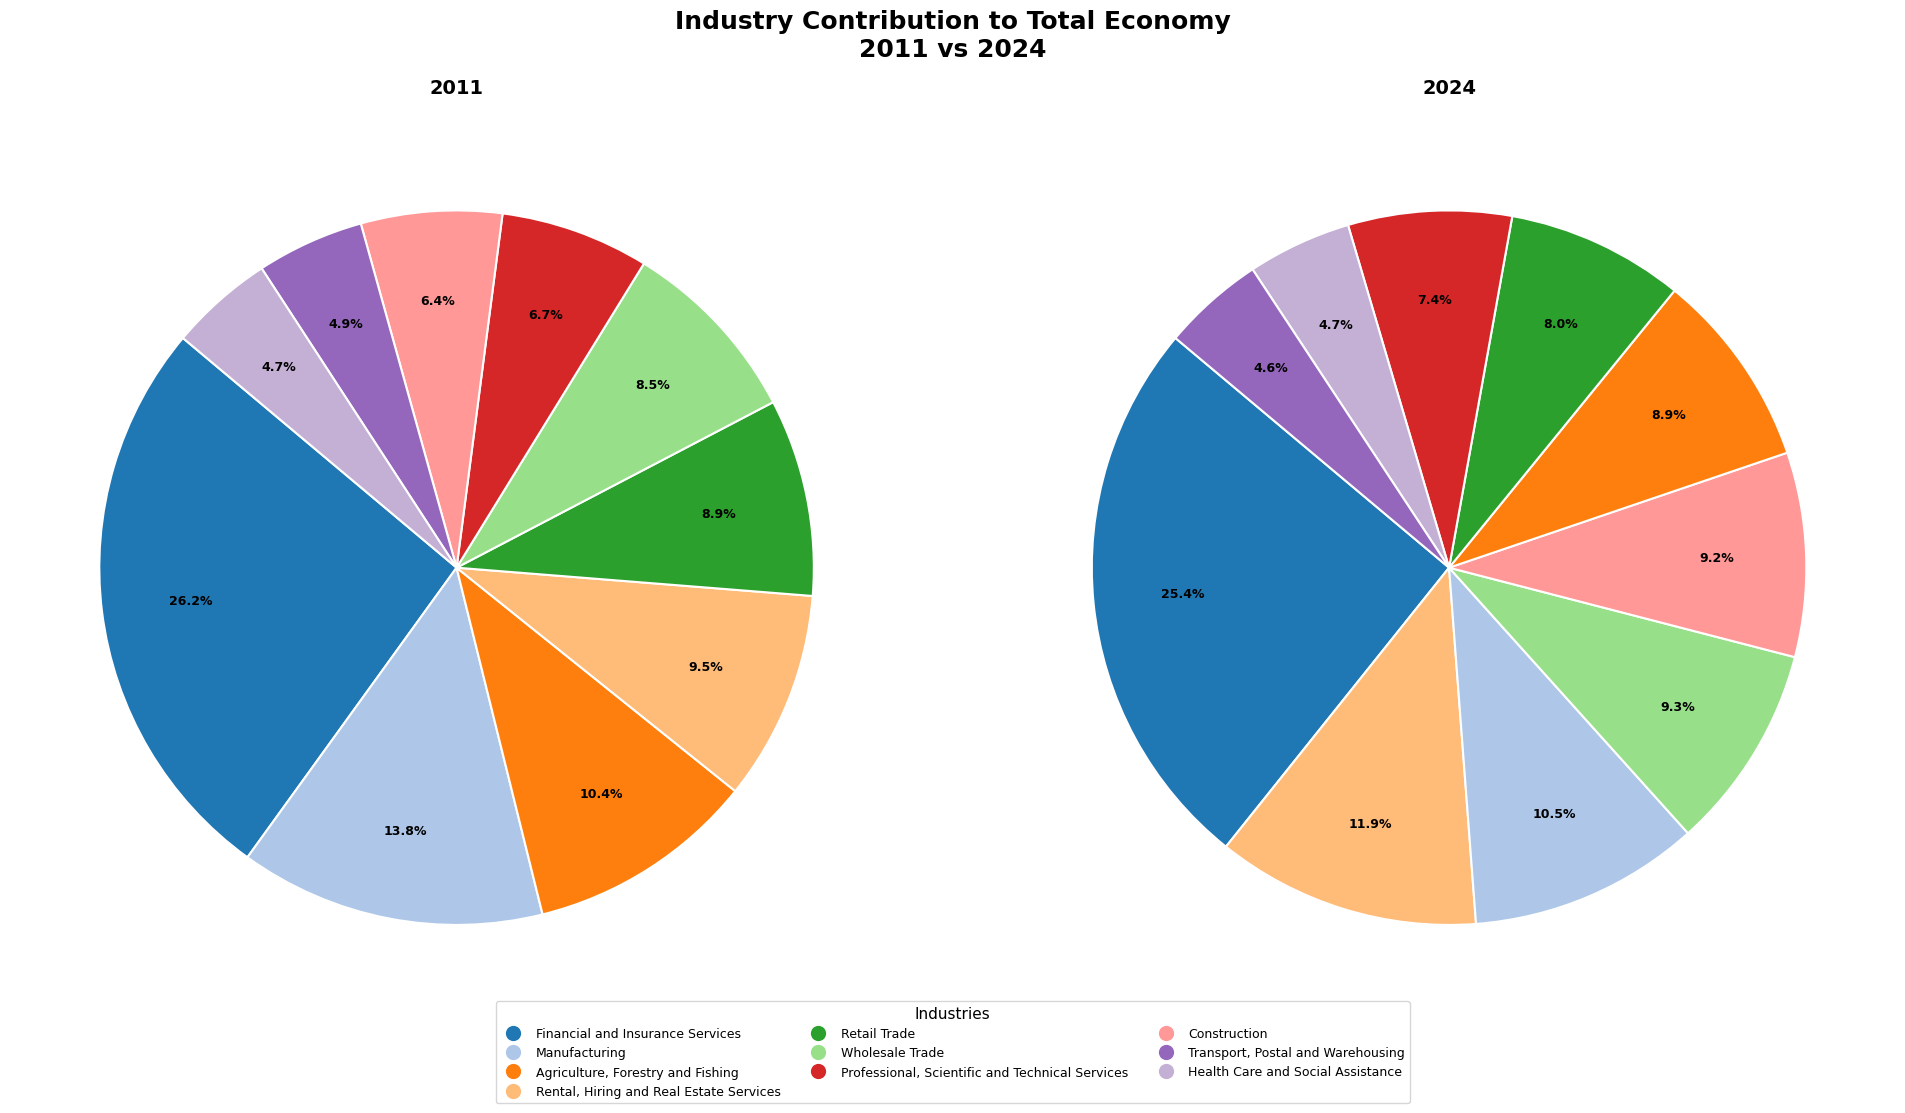

In [32]:
#Pie chart showing the percentage contributions of each industry to the economy in 2011 and 2024
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle('Industry Contribution to Total Economy\n2011 vs 2024',
             fontsize=18, fontweight='bold', y=1.02)

# Shared colour map across both charts 
all_industries = pd.concat([top10_2011['Industry'], top10_2024['Industry']]).unique()
colors         = plt.cm.tab20.colors
color_map      = {industry: colors[i] for i, industry in enumerate(all_industries)}

# 2011 Pie Chart 
sizes_2011  = top10_2011['Total Revenue (Millions NZD)']
colors_2011 = [color_map[ind] for ind in top10_2011['Industry']]

wedges_2011, _, autotexts_2011 = axes[0].pie(
    sizes_2011,
    labels=None,
    autopct='%1.1f%%',
    colors=colors_2011,
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for text in autotexts_2011:
    text.set_fontsize(9)
    text.set_fontweight('bold')

axes[0].set_title('2011', fontsize=14, fontweight='bold', pad=20)

# 2024 Pie Chart 
sizes_2024  = top10_2024['Total Revenue (Millions NZD)']
colors_2024 = [color_map[ind] for ind in top10_2024['Industry']]

wedges_2024, _, autotexts_2024 = axes[1].pie(
    sizes_2024,
    labels=None,
    autopct='%1.1f%%',
    colors=colors_2024,
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for text in autotexts_2024:
    text.set_fontsize(9)
    text.set_fontweight('bold')

axes[1].set_title('2024', fontsize=14, fontweight='bold', pad=20)

# Single shared legend 
legend_handles = [plt.Line2D([0], [0], marker='o', color='w',
                  markerfacecolor=color_map[ind], markersize=12, label=ind)
                  for ind in all_industries]

fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           fontsize=9, title='Industries', title_fontsize=11,
           bbox_to_anchor=(0.5, -0.08), frameon=True)

plt.tight_layout()
plt.savefig('pie_chart_2011_vs_2024.png', dpi=150, bbox_inches='tight')
plt.show()

Finance contributed the largest share in both years, while Real Estate and Construction gained a larger share by 2024.

In [33]:
def compute_yoy(code):
    """Compute year-on-year revenue stats for a given ANZSIC industry code."""
    yoy = (
        df[df['industry_code_ANZSIC'] == code]
        .groupby('year')['value']
        .sum()
        .reset_index()
        .rename(columns={'value': 'Total Revenue (Millions NZD)'})
    )
    yoy['YoY Change (Millions NZD)'] = yoy['Total Revenue (Millions NZD)'].diff()
    yoy['YoY % Change']              = yoy['Total Revenue (Millions NZD)'].pct_change() * 100
    yoy.index += 1
    return yoy


def plot_yoy(df_yoy, code, name, palette, savefile):
    """Plot three-panel YoY analysis and save to PNG."""
    fig, axes = plt.subplots(3, 1, figsize=(12, 15))
    fig.suptitle(f'{name} ({code})\nYear-on-Year Analysis 2011–2024',
                 fontsize=16, fontweight='bold', y=1.01)

    # 1. Total Revenue per Year
    sns.barplot(data=df_yoy, x='year', y='Total Revenue (Millions NZD)',
                hue='year', palette=palette, ax=axes[0], legend=False)
    axes[0].set_title('Total Revenue per Year', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Revenue (Millions NZD)')
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    axes[0].tick_params(axis='x', rotation=45)

    # 2. Year-on-Year Absolute Change
    colors = ['tomato' if v < 0 else 'seagreen'
              for v in df_yoy['YoY Change (Millions NZD)'].fillna(0)]
    axes[1].bar(df_yoy['year'], df_yoy['YoY Change (Millions NZD)'].fillna(0), color=colors)
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_title('Year-on-Year Absolute Change', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Year')
    axes[1].set_ylabel('Revenue (Millions NZD)')
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    axes[1].tick_params(axis='x', rotation=45)

    # 3. Year-on-Year % Change
    colors_pct = ['tomato' if v < 0 else 'seagreen'
                  for v in df_yoy['YoY % Change'].fillna(0)]
    bars = axes[2].bar(df_yoy['year'], df_yoy['YoY % Change'].fillna(0), color=colors_pct)
    axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[2].set_title('Year-on-Year % Change', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Year')
    axes[2].set_ylabel('% Change')
    axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
    axes[2].tick_params(axis='x', rotation=45)

    for bar, pct in zip(bars, df_yoy['YoY % Change'].fillna(0)):
        axes[2].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + (0.3 if pct >= 0 else -0.8),
                     f'{pct:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig(savefile, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {savefile}')


In [34]:
yoy_K = compute_yoy('K')
print('Year-on-Year Analysis: Financial and Insurance Services (K) 2011–2024')
print('=' * 75)
print(yoy_K.to_string())

Year-on-Year Analysis: Financial and Insurance Services (K) 2011–2024
    year  Total Revenue (Millions NZD)  YoY Change (Millions NZD)  YoY % Change
1   2011                     2411805.0                        NaN           NaN
2   2012                     2455656.0                    43851.0      1.818182
3   2013                     2364424.0                   -91232.0     -3.715178
4   2014                     2444200.0                    79776.0      3.374014
5   2015                     2614941.0                   170741.0      6.985558
6   2016                     2772232.0                   157291.0      6.015088
7   2017                     2825184.0                    52952.0      1.910085
8   2018                     2930553.0                   105369.0      3.729633
9   2019                     3119008.0                   188455.0      6.430698
10  2020                     3173767.0                    54759.0      1.755654
11  2021                     3365559.0            

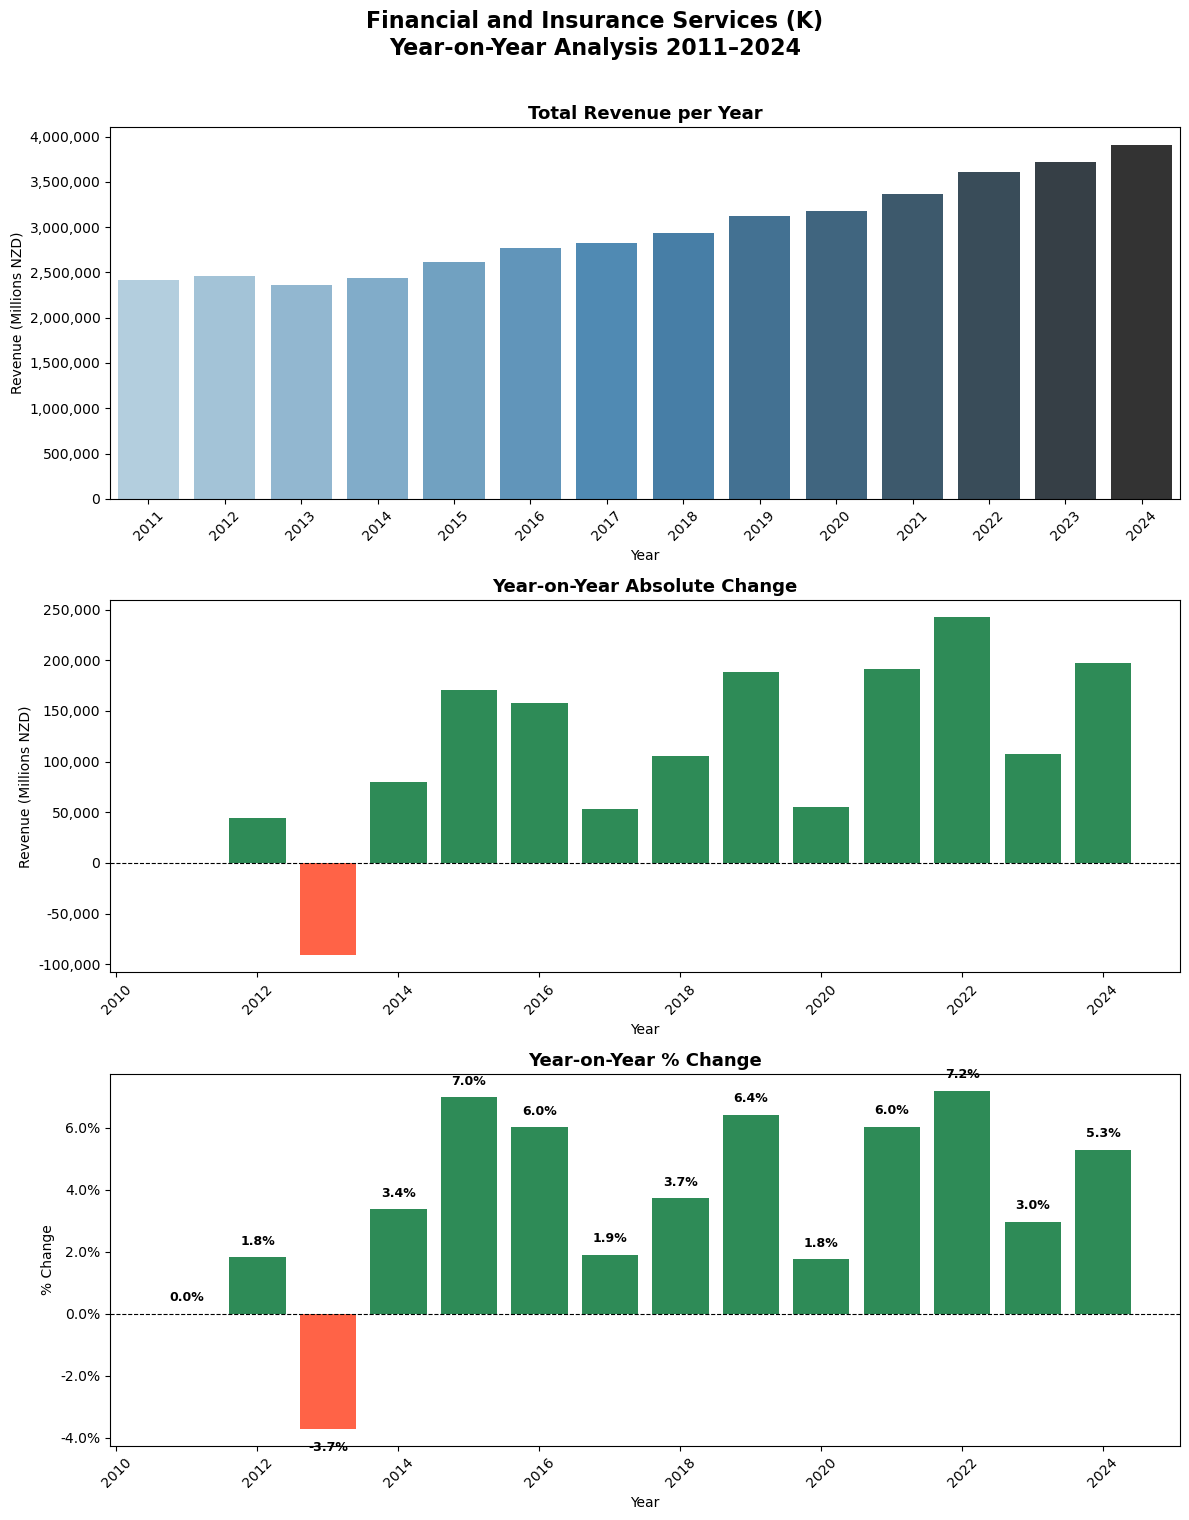

Saved: yoy_K_financial_insurance_cleaned.png


In [35]:
plot_yoy(yoy_K, 'K', 'Financial and Insurance Services', 'Blues_d',
         'yoy_K_financial_insurance_cleaned.png')

The sector showed steady long-term growth with only minor yearly fluctuations, highlighting its economic stability.

In [36]:
yoy_L = compute_yoy('L')
print('Year-on-Year Analysis: Rental, Hiring and Real Estate Services (L) 2011–2024')
print('=' * 75)
print(yoy_L.to_string())

Year-on-Year Analysis: Rental, Hiring and Real Estate Services (L) 2011–2024
    year  Total Revenue (Millions NZD)  YoY Change (Millions NZD)  YoY % Change
1   2011                      875506.0                        NaN           NaN
2   2012                      905334.0                    29828.0      3.406944
3   2013                      938279.0                    32945.0      3.638988
4   2014                      966078.0                    27799.0      2.962765
5   2015                     1052271.0                    86193.0      8.921950
6   2016                     1121242.0                    68971.0      6.554490
7   2017                     1195456.0                    74214.0      6.618910
8   2018                     1268035.0                    72579.0      6.071240
9   2019                     1379240.0                   111205.0      8.769868
10  2020                     1472808.0                    93568.0      6.784026
11  2021                     1554132.0     

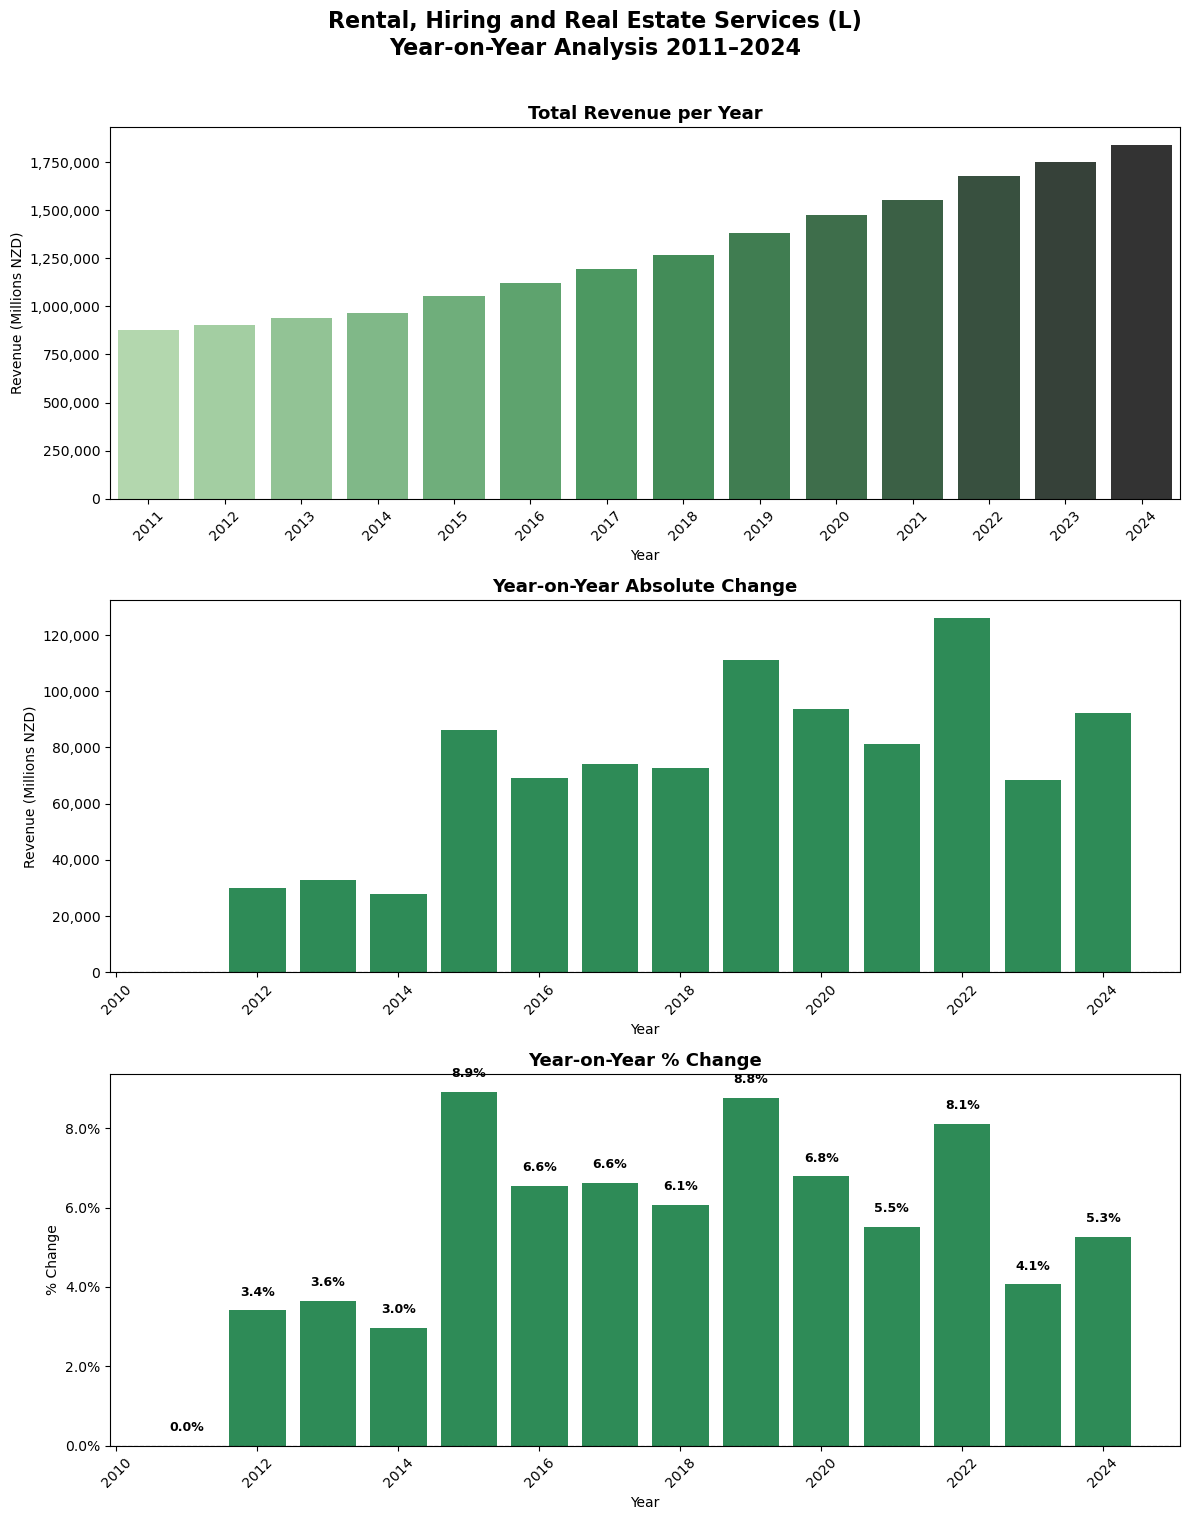

Saved: yoy_L_rental_real_estate.png


In [37]:
plot_yoy(yoy_L, 'L', 'Rental, Hiring and Real Estate Services', 'Greens_d',
         'yoy_L_rental_real_estate.png')

Real Estate revenue increased consistently over the years, suggesting rising investment and demand in the property sector.

In [38]:
yoy_A = compute_yoy('A')
print('Year-on-Year Analysis: Agriculture, Forestry and Fishing (A) 2011–2024')
print('=' * 75)
print(yoy_A.to_string())

Year-on-Year Analysis: Agriculture, Forestry and Fishing (A) 2011–2024
    year  Total Revenue (Millions NZD)  YoY Change (Millions NZD)  YoY % Change
1   2011                      956289.0                        NaN           NaN
2   2012                      981298.0                    25009.0      2.615214
3   2013                      977816.0                    -3482.0     -0.354836
4   2014                     1019889.0                    42073.0      4.302752
5   2015                     1057814.0                    37925.0      3.718542
6   2016                     1073602.0                    15788.0      1.492512
7   2017                     1120211.0                    46609.0      4.341367
8   2018                     1161882.0                    41671.0      3.719924
9   2019                     1206129.0                    44247.0      3.808218
10  2020                     1230450.0                    24321.0      2.016451
11  2021                     1253487.0           

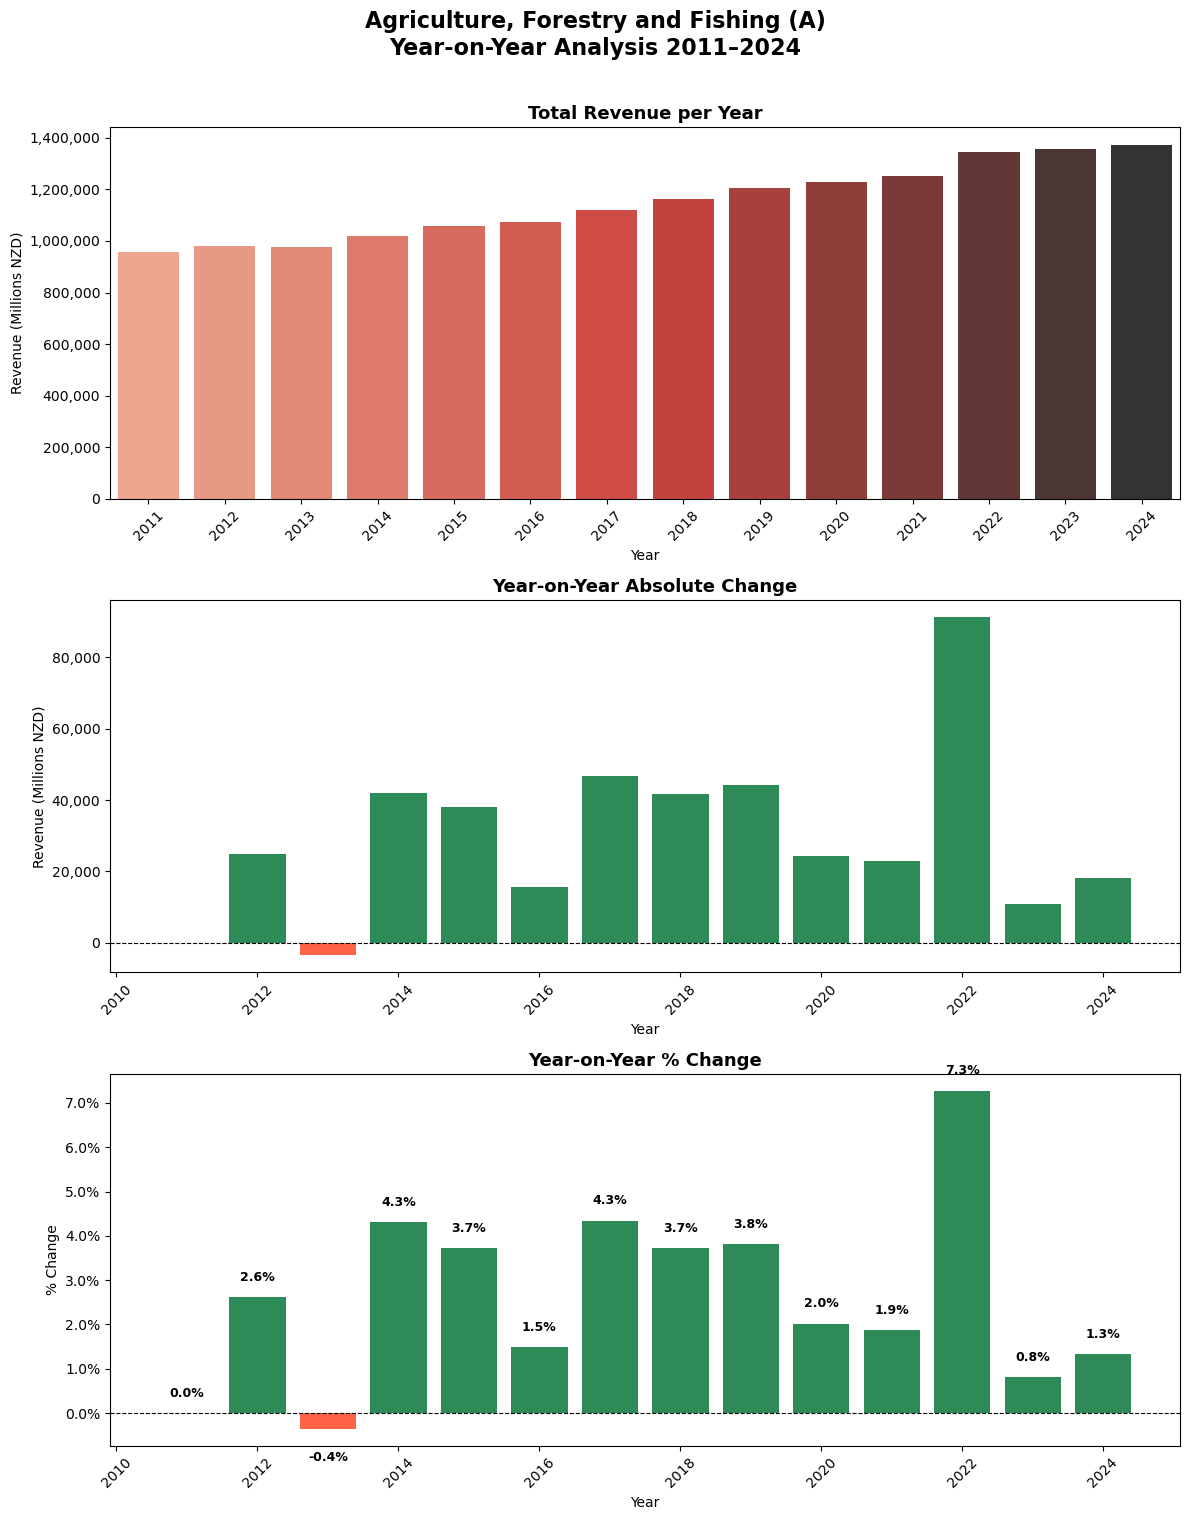

Saved: yoy_A_agriculture_forestry_fishing.png


In [39]:
plot_yoy(yoy_A, 'A', 'Agriculture, Forestry and Fishing', 'Reds_d',
         'yoy_A_agriculture_forestry_fishing.png')

Establishing the relationship between Real Estate and the Construction Industry

Inspecting the correlation between Real Estate and Construction Industry

Pearson Correlation (Construction vs Real Estate): r = 0.9964


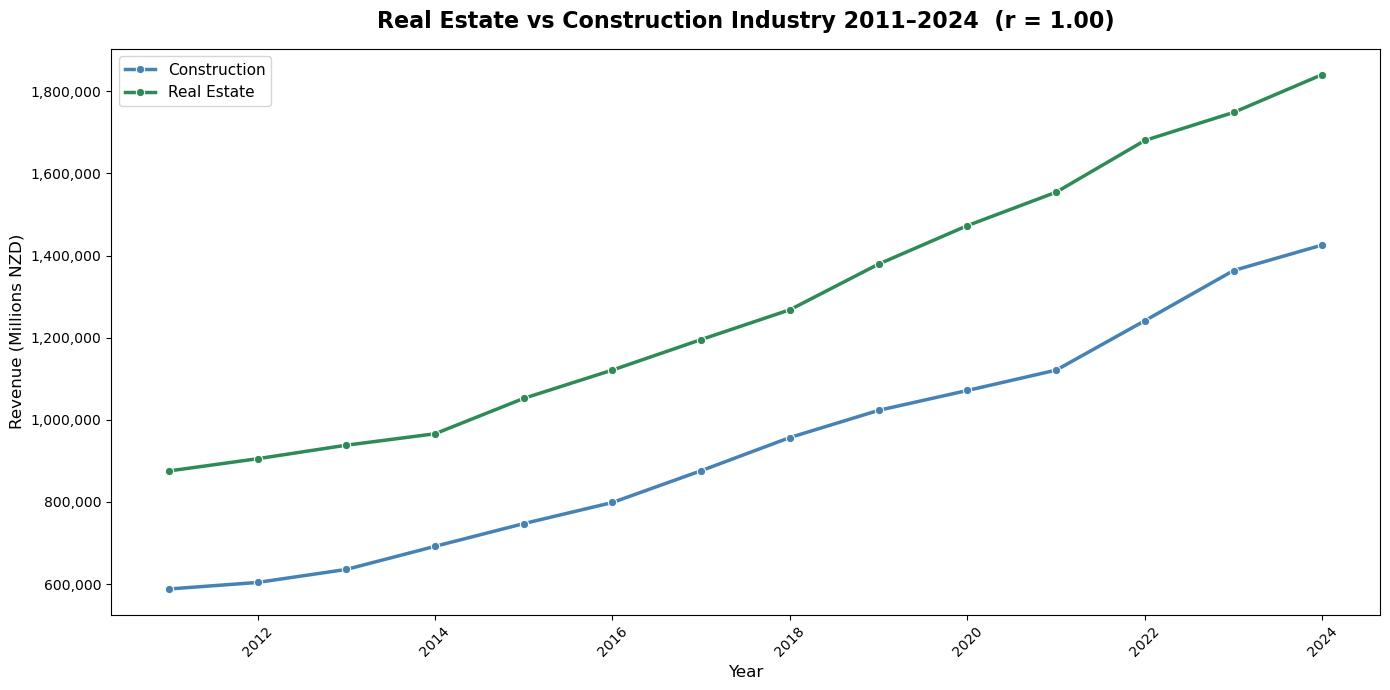

In [40]:
# Prepare data for Real Estate (L) and Construction (E)
yoy_E = (
    df[df['industry_code_ANZSIC'] == 'E']
    .groupby('year')['value']
    .sum()
    .reset_index()
    .rename(columns={'value': 'Construction (Millions NZD)'})
)

yoy_L_corr = (
    df[df['industry_code_ANZSIC'] == 'L']
    .groupby('year')['value']
    .sum()
    .reset_index()
    .rename(columns={'value': 'Real Estate (Millions NZD)'})
)

# Merge on year
corr_df = pd.merge(yoy_E, yoy_L_corr, on='year')
corr_value = corr_df['Construction (Millions NZD)'].corr(corr_df['Real Estate (Millions NZD)'])

# FIX 4: Print and display the correlation value (was computed but never shown)
print(f'Pearson Correlation (Construction vs Real Estate): r = {corr_value:.4f}')

# Dual Line Chart — include r in the title so the number is visible
fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(data=corr_df, x='year', y='Construction (Millions NZD)',
             marker='o', color='steelblue', linewidth=2.5, label='Construction', ax=ax)
sns.lineplot(data=corr_df, x='year', y='Real Estate (Millions NZD)',
             marker='o', color='seagreen', linewidth=2.5, label='Real Estate', ax=ax)

# FIX 4: r value embedded in title
ax.set_title(f'Real Estate vs Construction Industry 2011–2024  (r = {corr_value:.2f})',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Revenue (Millions NZD)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('correlation_real_estate_construction.png', dpi=150, bbox_inches='tight')
plt.show()


From the above image, it is apparent that Real Estate and construction are positvely correlated. An increase in the revenue for Real Estate led to an increase in revenue for Construction industry. 

Heatmap: Total Revenue of All Industries, 2011–2024

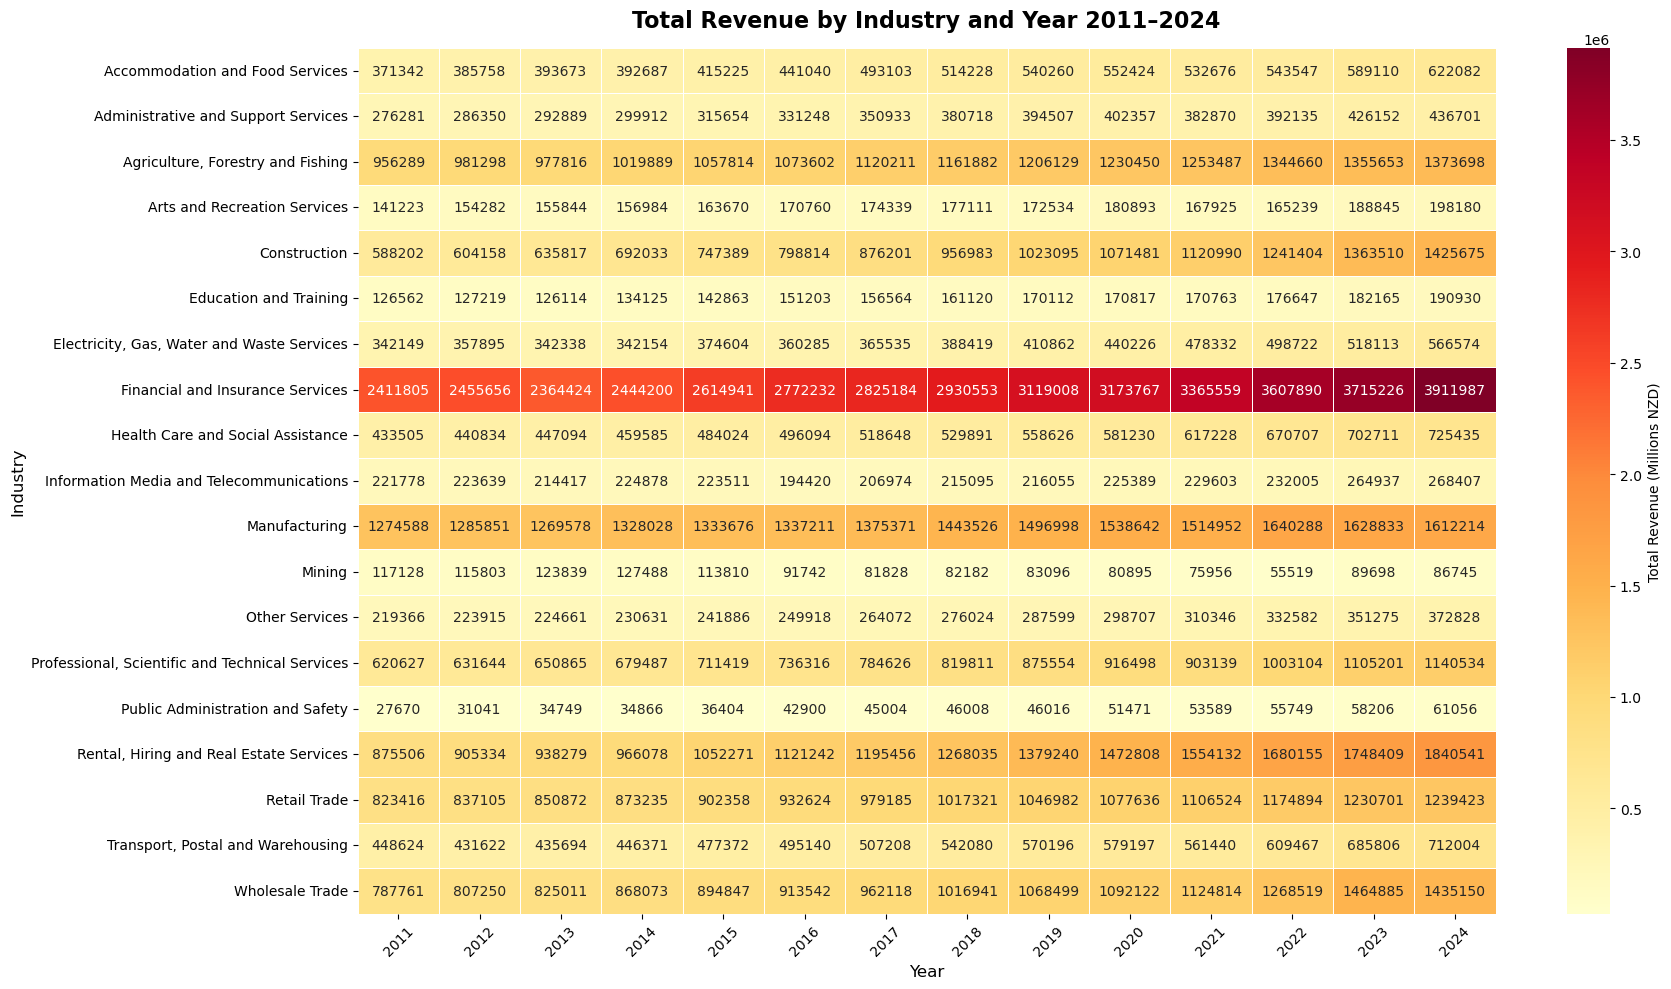

In [41]:
# Data of all industries over time 
heatmap_df = (
    df[df['industry_code_ANZSIC'] != 'all']
    .groupby(['industry_name_ANZSIC', 'year'])['value']
    .sum()
    .reset_index()
    .pivot(index='industry_name_ANZSIC', columns='year', values='value')
)

# Plot Heatmap 
fig, ax = plt.subplots(figsize=(18, 10))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Total Revenue (Millions NZD)'},
    ax=ax
)

ax.set_title('Total Revenue by Industry and Year 2011–2024',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Industry', fontsize=12)
ax.tick_params(axis='y', rotation=0)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('heatmap_all_industries.png', dpi=150, bbox_inches='tight')
plt.show()